In [2]:
import pandas as pd
import numpy as np
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
from dotenv import load_dotenv
import pyarrow as pa, pyarrow.parquet as pq, pyarrow.compute as pc
import gc

In [3]:
sys.path.append(os.path.abspath("../src"))
from estimator import SegmentEstimator

In [4]:
load_dotenv()
PROPENSITY_PATH = os.getenv("PROPENSITY_PATH")
propensity_path = PROPENSITY_PATH

In [5]:
run_segment_cols = [
    'propensity',
    'is_algo',
    'y_like_24h',
    'y_dislike_24h'
]

distribution_cols = ['propensity',
        'is_algo'
]

smd_cols = [
    'propensity',
    'is_algo',
    'u_algo_rate_smoothed',
    'u_item_seen_before',
    'item_like_rate_smoothed',
    'u_like_rate_smoothed',
    'log_item_prior_plays',
    'log_u_prior_plays',
    'u_dislike_rate_smoothed',
    'item_dislike_rate_smoothed'
]

smd_plot_cols = [
    'u_algo_rate_smoothed',
    'u_item_seen_before',
    'item_like_rate_smoothed',
    'u_like_rate_smoothed',
    'log_item_prior_plays',
    'log_u_prior_plays',
    'u_dislike_rate_smoothed',
    'item_dislike_rate_smoothed'
]

## **Core Drivers**

In [6]:
estimator = SegmentEstimator(propensity_path)

# user_average_segment × item_very_popular_segment
segment_1 = ["log_u_prior_plays > 3 AND log_u_prior_plays <= 4",
             "log_item_prior_plays > 3"]

# user_average_segment × rare_likers_segment
segment_2 = ["log_u_prior_plays > 3 AND log_u_prior_plays <= 4",
             "u_like_rate_smoothed >= 0 AND u_like_rate_smoothed <= 0.1"]

# item_popular_segment × rare_likers_segment
segment_3 = ["log_item_prior_plays > 1 AND log_item_prior_plays <= 3",
             "u_like_rate_smoothed >= 0 AND u_like_rate_smoothed <= 0.1"]

# item_very_popular_segment × rare_likers_segment
segment_4 =  ["log_item_prior_plays > 3",
              "u_like_rate_smoothed >= 0 AND u_like_rate_smoothed <= 0.1"]

# user_average_segment × item_popular_segment × rare_likers_segment
segment_5 = ["log_u_prior_plays > 3 AND log_u_prior_plays <= 4",
             "log_item_prior_plays > 1 AND log_item_prior_plays <= 3",
             "u_like_rate_smoothed >= 0 AND u_like_rate_smoothed <= 0.1"]

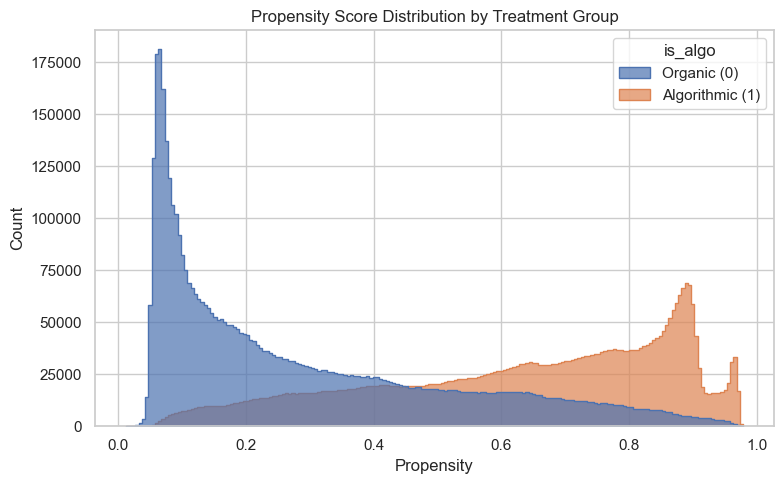

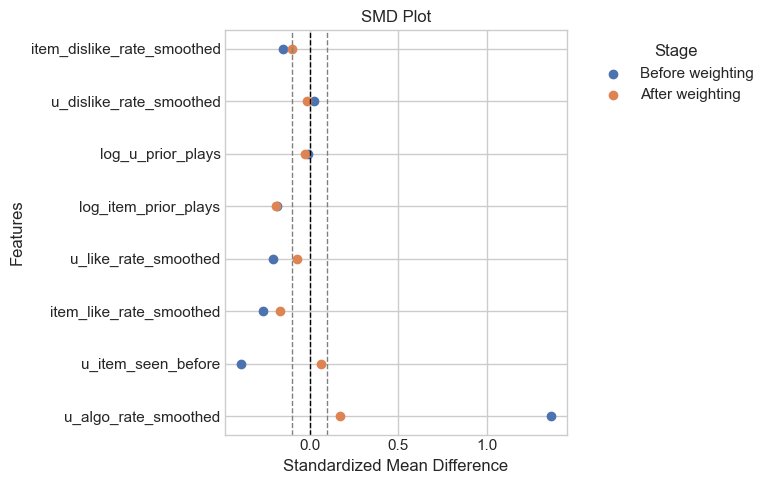

,metric,value
0,n_original,9256718
1,n_trimmed,9256718
2,pct_dropped,0.0 %
3,propensity_min,0.01259
4,propensity_max,0.97784
5,ESS,5216417.524
6,ATE_like,0.0094
7,ATE_dislike,0.00067


In [7]:
# segment 1
segment_1_df = estimator.load_segment(segment_1,distribution_cols)
estimator.propensity_distribution_plot(segment_1_df)
del segment_1_df
segment_1_df = estimator.load_segment(segment_1,smd_cols)
estimator.smd_plot(segment_1_df, smd_plot_cols)
del segment_1_df
segment_1_df = estimator.load_segment(segment_1,run_segment_cols)
result = estimator.run_segment(segment_1_df)
del segment_1_df
gc.collect()
result


- SMDs drop after IPTW, meaning treated and control groups become more comparable
- Algorithmic recommendations increase likes by +9.4 per 1,000 listens while increasing dislikes only by +0.67 per 1,000; clear positive net benefit for algorithmic recommendations in this segment



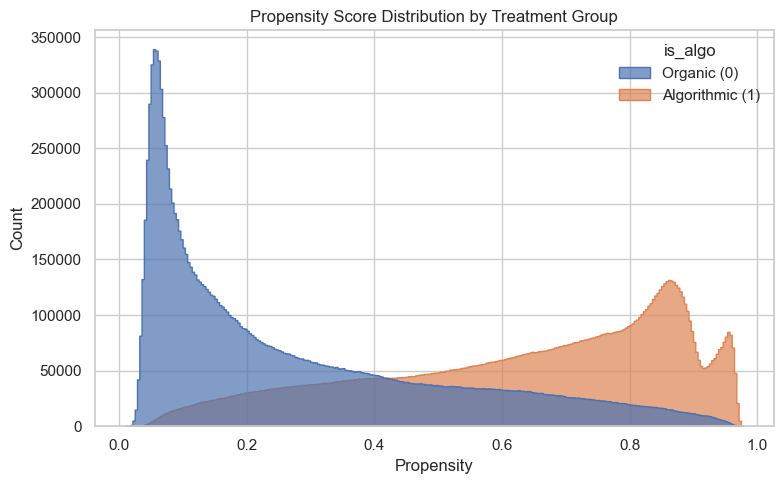

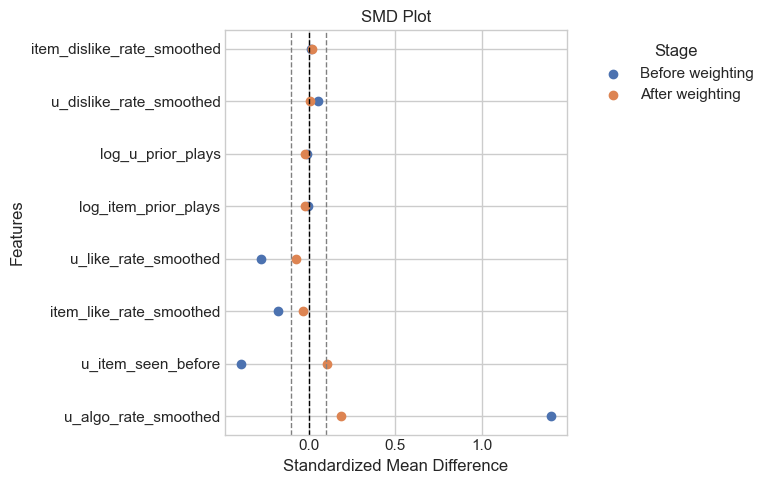

,metric,value
0,n_original,29609372
1,n_trimmed,29609335
2,pct_dropped,0.00012 %
3,propensity_min,0.00461
4,propensity_max,0.97784
5,ESS,16218250.755
6,ATE_like,0.00909
7,ATE_dislike,0.00124


In [8]:
# segment 2
segment_2_df = estimator.load_segment(segment_2,distribution_cols)
estimator.propensity_distribution_plot(segment_2_df)
del segment_2_df
segment_2_df = estimator.load_segment(segment_2,smd_cols)
estimator.smd_plot(segment_2_df, smd_plot_cols)
del segment_2_df
segment_2_df = estimator.load_segment(segment_2,run_segment_cols)
result = estimator.run_segment(segment_2_df)
del segment_2_df
gc.collect()
result

- IPTW reduces initial covariate imbalance, suggesting treated and control groups are reasonably comparable after weighting
- Algorithmic recommendations increase likes by +9.1 per 1,000 listens while also increasing dislikes by +1.24 per 1,000; algorithmic exposure improves overall engagement


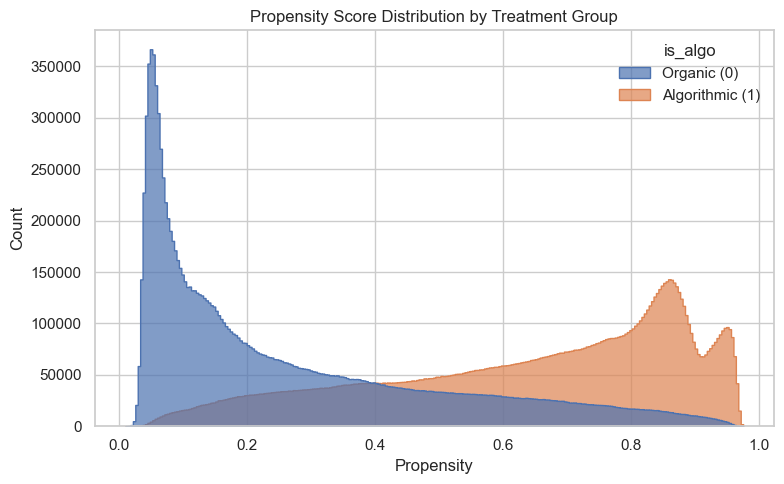

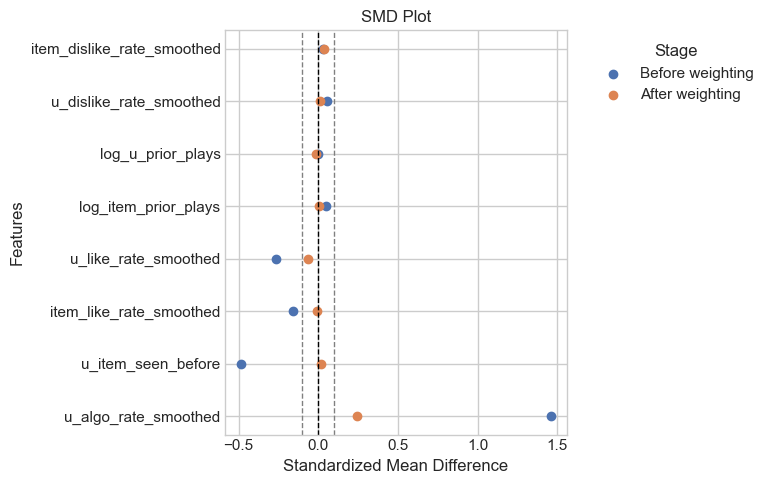

,metric,value
0,n_original,27520754
1,n_trimmed,27520720
2,pct_dropped,0.00012 %
3,propensity_min,0.00461
4,propensity_max,0.97462
5,ESS,15110569.289
6,ATE_like,0.00925
7,ATE_dislike,0.00152


In [9]:
# segment 3
segment_3_df = estimator.load_segment(segment_3,distribution_cols)
estimator.propensity_distribution_plot(segment_3_df)
del segment_3_df
segment_3_df = estimator.load_segment(segment_3,smd_cols)
estimator.smd_plot(segment_3_df, smd_plot_cols)
del segment_3_df
segment_3_df = estimator.load_segment(segment_3,run_segment_cols)
result = estimator.run_segment(segment_3_df)
del segment_3_df
gc.collect()
result

- IPTW reduces most covariate imbalances, meaning treated and control groups are reasonably comparable
- Algorithmic recommendations increase likes by +9.3 per 1,000 listens but also increase dislikes by +1.5 per 1,000; overall engagement improvement for this segment

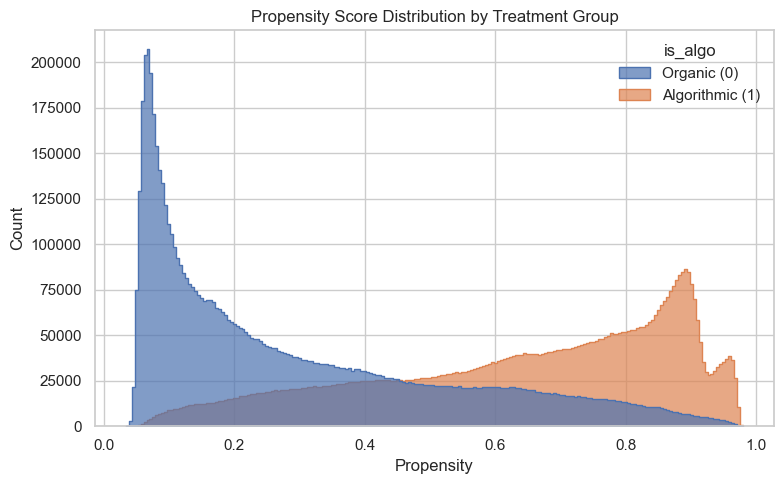

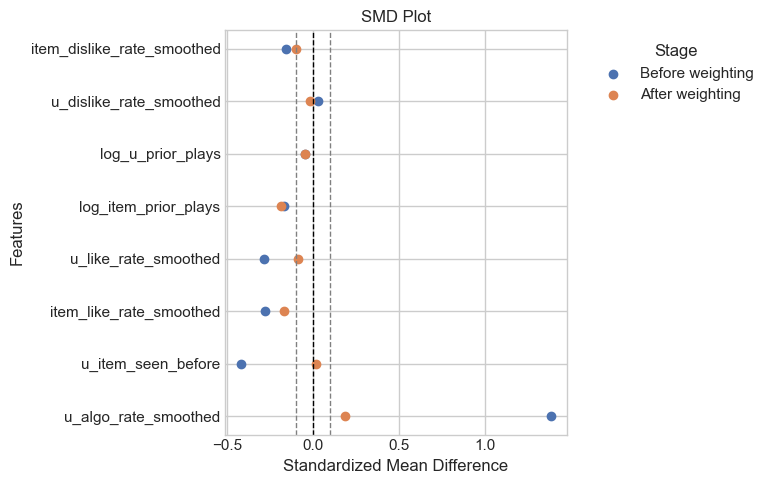

,metric,value
0,n_original,13670051
1,n_trimmed,13670051
2,pct_dropped,0.0 %
3,propensity_min,0.03342
4,propensity_max,0.97993
5,ESS,7749980.418
6,ATE_like,0.00791
7,ATE_dislike,0.00082


In [10]:
# segment 4
segment_4_df = estimator.load_segment(segment_4,distribution_cols)
estimator.propensity_distribution_plot(segment_4_df)
del segment_4_df
segment_4_df = estimator.load_segment(segment_4,smd_cols)
estimator.smd_plot(segment_4_df, smd_plot_cols)
del segment_4_df
segment_4_df = estimator.load_segment(segment_4,run_segment_cols)
result = estimator.run_segment(segment_4_df)
del segment_4_df
gc.collect()
result

- A few covariates are within the threshold, but several remain outside it, so this segment should not be presented as well balanced
- Algorithmic recommendations increase likes by +7.9 per 1,000 listens and dislikes by +0.82 per 1,000 listens within this segment; estimate should be interpreted with some caution


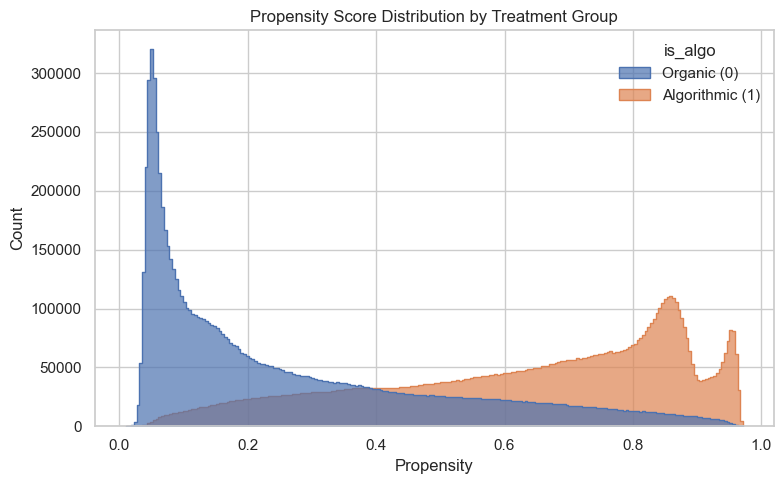

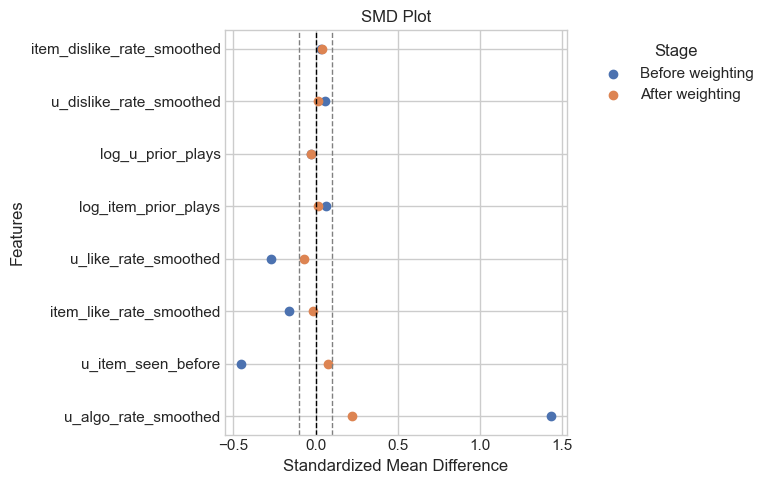

,metric,value
0,n_original,18346641
1,n_trimmed,18346619
2,pct_dropped,0.00012 %
3,propensity_min,0.00461
4,propensity_max,0.97156
5,ESS,10021270.699
6,ATE_like,0.00946
7,ATE_dislike,0.00151


In [11]:
# segment 5
segment_5_df = estimator.load_segment(segment_5,distribution_cols)
estimator.propensity_distribution_plot(segment_5_df)
del segment_5_df
segment_5_df = estimator.load_segment(segment_5,smd_cols)
estimator.smd_plot(segment_5_df, smd_plot_cols)
del segment_5_df
segment_5_df = estimator.load_segment(segment_5,run_segment_cols)
result = estimator.run_segment(segment_5_df)
del segment_5_df
gc.collect()
result

- IPTW reduces most initial imbalance, but some remain imbalanced, indicating potential residual confounding in this segment 
- Algorithmic recommendations increase likes by +9.5 per 1,000 listens and dislikes by +1.5 per 1,000 listens in this segment, estimates should be interpreted with some caution